# ¿Qué es **Apache KAFKA**?

Es una plataforma de **streaming distribuido**, que se utiliza para construir **aplicaciones basadas en datos en tiempo real**.

### ¿Qué significa que sea una plataforma de **streaming distribuido**?

Significa que está diseñada para **manejar flujos de datos en tiempo real** (**streaming**) y **hacerlo de forma distribuida**, es decir, repartida a través de múltiples servidores o nodos.

Entonces, es **capaz de ingerir y procesar datos a medida que se generan** (monitoreo de transacciones financieras, análisis de logs, sensores IoT...).
Además, el **flujo de datos es continuo**, lo que significa que los datos se están produciendo y consumiendo constantemente, sin necesidad de esperar a que se complete un conjunto antes de comenzar a procesarlo.

Es **horizontalmene escalable**, esto es, está diseñado para funcionar en un **cluster de múltiples servidores** (llamados **brokers** en Kafka), que permite añadir o quitar más servidores si el volumen de datos cambia (**elasticidad**) y optimizar el rendimiento.

Es **tolerante a fallos** por ser distribuido, ya que **replica los datos** en múltiples nodos o brokers.

Otra característica, es que **los datos en Kafka se dividen en particiones** dentro de cada topic. Esto permite que diferentes partes del mismo flujo de datos, **se procesen en paralelo**, en lugar de esperar a que el flujo de datos esté completo, lo que mejora significativamente la eficiencia y el rendimiento.

Apache Kafka implementa el patrón de diseño Pub-sub (publicación suscripción).
Este patrón implica que los emisores no envían directamente los mensajes a los destinatarios, sino que se publican en un "canal", al cual los suscriptores pueden suscribirse para recibir los mensajes. Este patrón, desacopla a los productores de los consumidores, permitiendo una mayor flexibilidad y escalabilidad.

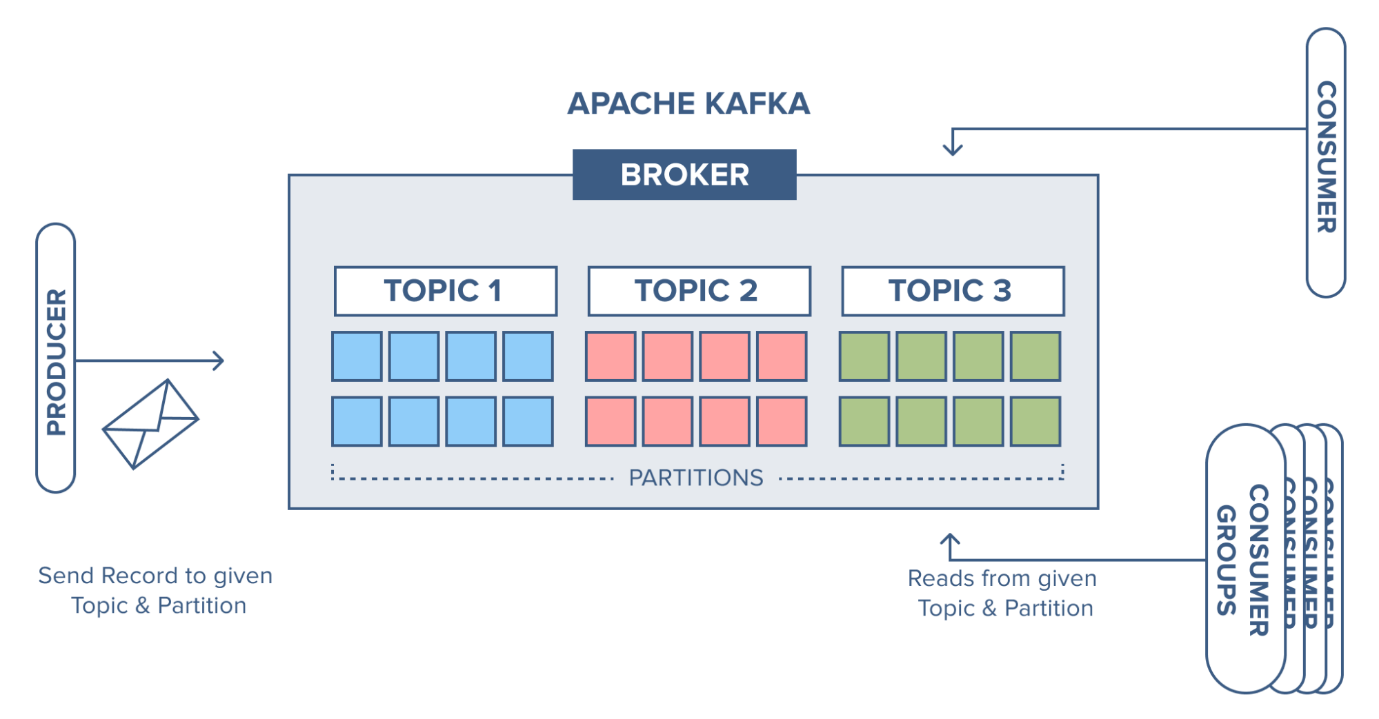

Una curiosidad: Kafka **fue creado por LinkedIn**, y posteriormente **donado** a la **Apache Foundation**, quien lo desarrolla actualmente 🤯

## Veamos la web de Apache Kafka:

https://kafka.apache.org/

## Veamos ahora una guia de los principales componentes de Kafka:

https://docs.cloudera.com/HDPDocuments/HDP2/HDP-2.6.3/bk_kafka-component-guide/content/ch_overview_kafka.html

## KAFKA además, funciona de la mano de **ZooKeeper**

**Apache ZooKeeper**, es un **servicio centralizado** que se encarga de **mantener la metadata**, es decir, la información de configuración, y de proporcionar **sincronización distribuida**. En el contexto de Kafka, desempeña un papel crucial en la **gestión del clúster de Kafka**.

En resumen, las **funciones de ZooKeeper en Kafka** son:



*   **Gestión de metadata del cluster** de Kafka (incluye información sobre los brokers, topics, particiones y estados de las réplicas). Esto permite que Kafka conozca la estructura del clúster y pueda coordinar las actividades entre los brokers.
*   **Control de líderes y réplicas**. En Kafka, cada partición tiene un broker que hace de lider, es decir, se encarga de manejar todas las operaciones de lectura y escritura para esa partición. ZooKeeper es quien seleccona al líder para cada partición y gestiona las réplicas.
*   **Gestión de la configuración del clúster**. Cualquier cambio en la configuración del cluster (nuevos topics, nuevos brokers...) se almacenan en ZooKeeper.
*   **Coordinación de la sincronización**. ZooKeeper facilita la coordinación entre los brokers, especialmente en operaciones que requieren consenso, como replicación y confirmaciones de escritura.
*  **Detección de fallos**. También se encarga de monitorear el estado de los brokers en el clúster, coordinando las acciones necesarias en caso de error.

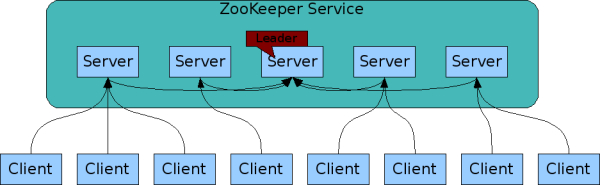


## Un pequeño **ejemplo práctico** para asentar la teoría:

Imaginemos que trabajamos para un banco, que necesita monitorear las transacciones bancarias en tiempo real para detectar fraudes. Utilizaremos para gestionar el flujo de datos Apache Kafka:



*   1- **Topic**
  *   Nombre del topic: 'transacciones bancarias'
  *   Particiones: 4 (para distribuir la carga de datos y permitir el procesamiento paralelo)
*   2- **Producers (Productores)**:
  *   Las aplicaciones que generan las transacciones bancarias, publican estos datos en el topic 'transacciones bancarias'
  Por ejemplo:
  ```
  { "transaccion_id": "T1001", "monto": 100.00, "cuenta_origen": "1234567890", "cuenta_destino": "0987654321", "timestamp": "2024-07-06T14:22:00Z" }
{ "transaccion_id": "T1002", "monto": 200.00, "cuenta_origen": "2234567890", "cuenta_destino": "1987654321", "timestamp": "2024-07-06T14:22:05Z" }
```
*   3- **Brokers**:
  *   Los datos de las transacciones se almacenan en diferentes brokers, distribuidos a través de múltiples servidores. Cada transacción se guarda en una partición específica del topic, y cada partición puede estar replicada en varios brokers para asegurar durabilidad.
  *   Configuración de los brokers: (Supongamos que tenemos 3 brokers):
  ```
  Broker 1: broker1:9092
  Broker 2: broker2:9092
  Broker 3: broker3:9092
  ```
*   4- **Consumers**:
  *   Las aplicaciones que necesitan procesar las transacciones, como por ejemplo la de detección de fraudes, se suscriben al topic 'transacciones bancarias' y leen los datos desde las particiones correspondientes.




### Ahora...


# Montemos un ejemplo con **Kafka** en Cloud

### Parte 1 - Instalación y configuración de **Kafka**

Vamos a crear un server de Kafka sencillo. Para ello, vamos a Compute Engine y **creamos una máquina con Ubuntu 20.04** (Esto ya sabemos hacerlo, ¿verdad?).

Una vez creada la máquina, en la consola vamos a descargar, instalar y configurar Kafka. Para ello, utilizaremos los siguientes comandos:

```bash
sudo apt-get update
sudo apt-get upgrade -y
sudo apt-get install default-jdk -y
wget https://archive.apache.org/dist/kafka/3.6.0/kafka_2.13-3.6.0.tgz
tar -xzf kafka_2.13-3.6.0.tgz
cd kafka_2.13-3.6.0
export IP=$(ip addr show | grep 'inet ' | grep -v '127.0.0.1' | awk '{print $2}' | cut -f1 -d'/')
echo "advertised.listeners=PLAINTEXT://$IP:9092" | sudo tee -a config/server.properties
cat config/server.properties
```

¿Conocemos los anteriores comandos?

export IP=$(ip addr show | grep 'inet ' | grep -v '127.0.0.1' | awk '{print $2}' | cut -f1 -d'/')

Este en particular lo que hace es obtener la dirección IP del server:
*   export IP=: Define y exporta una variable de entorno llamada IP.
*   $( ... ): Subshell que ejecuta los comandos dentro de los paréntesis y asigna la salida a la variable IP.

*   ip addr show: Muestra las direcciones IP asociadas con las interfaces de red en el servidor.
*   grep 'inet ': Filtra las líneas que contienen 'inet ' (direcciones IP).
*   grep -v '127.0.0.1': Excluye la línea que contiene '127.0.0.1' (la dirección de loopback local).
*   awk '{print $2}': Extrae la segunda columna de la salida (las direcciones IP con su máscara de subred).
*   cut -f1 -d'/': Corta la dirección IP de la máscara de subred, dejando solo la IP.

echo "advertised.listeners=PLAINTEXT://$IP:9092" | sudo tee -a config/server.properties

Este otro, agrega la dirección IP a la configuración de Kafka

*   echo "advertised.listeners=PLAINTEXT://$IP:9092": Crea una cadena que define el listener de Kafka, utilizando la dirección IP almacenada en la variable IP y el puerto 9092.
*   sudo tee -a config/server.properties: Ejecuta tee con permisos de superusuario (sudo). tee toma la entrada desde stdin y la añade (-a significa append) al archivo config/server.properties.

En resumen, estos últimos dos comandos **configuran el servidor Kafka** para que se anuncie utilizando la dirección IP de la máquina y el **puerto 9092**. Así, Kafka ya puede comunicarse con una red (fundamental en entornos distribuidos, ¿no?)



### Parte 2 - Ejecución de ZooKeeper

 En el mismo directorio de Kafka, **ejecutamos ZooKeeper**:

``` bash
bin/zookeeper-server-start.sh config/zookeeper.properties
```

### Parte 3 - Ejecución de Kafka

Kafka se va a arrancar como server. ZooKeeper ya está configurado para crear un cluster y elegir este servicio de Kafka como líder (obviamente, ya que no hay ningún otro servicio ahora mismo).

Para esto, vamos a abrir un **nuevo terminal del server**, y en él, arrancaremos Kafka:

``` bash
cd
cd kafka_2.13-3.6.0
bin/kafka-server-start.sh config/server.properties
```

### Parte 4 - Creamos el topic test y lo probamos

Vamos a abrir una tercera terminal en la instancia de Kafka y crearemos un topic llamado test:

```bash
cd
cd kafka_2.13-3.6.0
bin/kafka-topics.sh --create --bootstrap-server localhost:9092 --replication-factor 1 --partitions 1 --topic test
bin/kafka-topics.sh --list --bootstrap-server localhost:9092
```

Si todo ha ido bien, ahora podemos arrancar un "Console Producer"

```bash
cd
cd kafka_2.13-3.6.0
bin/kafka-console-producer.sh --bootstrap-server localhost:9092 --topic test
```

Y ahora, podemos enviarle "eventos" cada que escribamos algo y presionemos "enter" en la consola!

### Parte 4 - Conectamos con Hadoop via Flume

**Apache Flume**, también es un servicio de Apache para **recopilar grandes cantidades de datos** streaming, en particular, **registros y eventos**.

Flume envía datos a los consumidores mediante mecanismos que llama "**sumideros de datos**". Flume es capaz de enviar estos datos a muchos sumideros populares en tiempo real, como HDFS, **HBase**, Cassandra y también algunas bases de datos relacionales.

Por sintetizar, es una herramienta que transfiere grandes cantidades de datos de registro y eventos desde diversas fuentes, hasta un almacén centralizado.

**Dato freak**: Originalmente desarrollado por Cloudera, también fue donado a Apache Foundation.

**Flume y Kafka**, son herramientas complementarias dentro del ecosistema Big Data, y se pueden integrar para crear un sistema robusto de ingesta y procesamiento de datos. Mientras **Flume ingiere datos**, **Kafka**, como plataforma de streaming distribuido, puede actuar como un **sistema de mensajería para datos en tiempo real**.

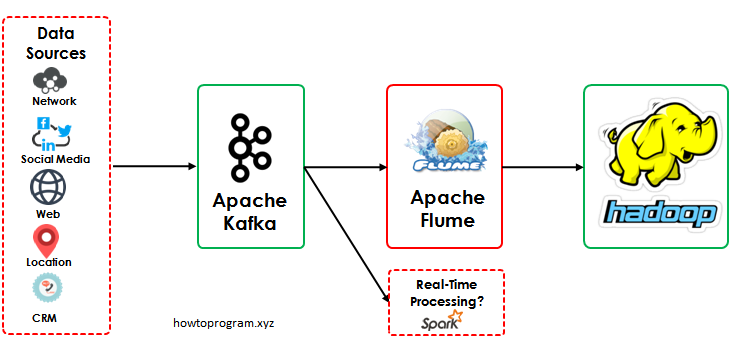

La configuración que llevaremos a cabo con Flume es bastante simple, pero esta herramienta tiene muchas posibilidades y configuraciones específicas para cada caso: https://flume.apache.org/FlumeUserGuide.html

Además, Flume no es la única opción para este tipo de soluciones:
https://tdwi.org/articles/2016/04/15/streaming-data-kafka-kinesis-flume-storm.aspx

Volviendo al ejercicio...

Ahora tenemos que **crear un cluster con Hadoop** para poder hacer la conexión de Kafka con Hadoop vía Flume así que...



1.   **Creamos un cluster Dataproc** en la misma región que el Kafka (¿nos acordamos cómo?)
2.  ** Abrimos una terminal en el master** del cluster Dataproc para conectar con Kafka
3.   **Creamos una carpeta para Flume** y lo descargamos:

```bash
sudo mkdir /usr/lib/flume
sudo chmod -R 777 /usr/lib/flume
cd /usr/lib/flume
wget http://apache.rediris.es/flume/1.11.0/apache-flume-1.11.0-bin.tar.gz
ls
tar -xzf apache-flume-1.11.0-bin.tar.gz
```

Ahora, vamos a **configurar** el archivo `.bashrc` en el home, que es donde se encuentran las **variables de entorno**. Debemos configurar algunas para **Flume**:

```bash
sed -i '$a \export FLUME_HOME="/usr/lib/flume/apache-flume-1.11.0-bin" \nexport FLUME_CONF_DIR="$FLUME_HOME/conf" \nexport FLUME_CLASSPATH="$FLUME_CONF_DIR"\nexport PATH="$FLUME_HOME/bin:$PATH"' ~/.bashrc
```

Tras esto, refrescamos el archivo `.bashrc` y entramos en la carpeta de **configuración de Flume**:

```
source ~/.bashrc

cd $FLUME_CONF_DIR

cp flume-env.sh.template flume-env.sh

cp flume-conf.properties.template flume-conf.properties

rm /$FLUME_HOME/lib/guava-11.0.2.jar
```

Luego, en el archivo de environment de Flume (`flume-env.sh`), configuramos más variables de entorno (en el caso de Flume, hay más configuraciones que hacer que en otras herramientas, pero por suerte estas configuraciones sólo se hacen una vez y los comandos suelen estar indicados en la web de Apache o en distintos foros, para una diversidad de casos de uso):

```bash
cd $FLUME_CONF_DIR

sed -i '$a \export JAVA_HOME=/usr/lib/jvm/temurin-11-jdk-amd64\nexport JAVA_OPTS="-Xms100m -Xmx2000m -Dcom.sun.management.jmxremote"' flume-env.sh
```

Finalmente, para confirmar que todos los cambios que hemos hecho en la configuración han ido bien, ejecutaremos este comando:

```
flume-ng help
```

Si no falla, significa que todo ha ido bien y que Flume está correctamente instalado y configurado.


Ahora, para que la conexión funcione, debemos buscar la IP PRIVADA de la máquina Kafka y ejecutar este comando:

```bash
export KAFKA_IP="XXXXX"

echo $KAFKA_IP
```

Finalmente, tras haber configurado correctamente Flume, vamos a crear un CONSUMER para Kafka, definiendo un archivo de configuración nuevo (`kafka.conf`):

```bash
cd $FLUME_CONF_DIR
rm kafka.conf
touch kafka.conf

echo $'flume1.sources  = kafka-source-1\nflume1.channels = hdfs-channel-1\nflume1.sinks    = hdfs-sink-1\nflume1.sources.kafka-source-1.type = org.apache.flume.source.kafka.KafkaSource\nflume1.sources.kafka-source-1.kafka.bootstrap.servers = '"$KAFKA_IP"$':9092\nflume1.sources.kafka-source-1.topic =test\nflume1.sources.kafka-source-1.batchSize = 100\nflume1.sources.kafka-source-1.channels = hdfs-channel-1\n\nflume1.channels.hdfs-channel-1.type   = memory\nflume1.sinks.hdfs-sink-1.channel = hdfs-channel-1\nflume1.sinks.hdfs-sink-1.type = hdfs\nflume1.sinks.hdfs-sink-1.hdfs.writeFormat = Text\nflume1.sinks.hdfs-sink-1.hdfs.fileType = DataStream\nflume1.sinks.hdfs-sink-1.hdfs.filePrefix = test-events\nflume1.sinks.hdfs-sink-1.hdfs.useLocalTimeStamp = true\nflume1.sinks.hdfs-sink-1.hdfs.path = /tmp/kafka/%{topic}/%y-%m-%d\nflume1.sinks.hdfs-sink-1.hdfs.rollCount=100\nflume1.sinks.hdfs-sink-1.hdfs.rollSize=0\nflume1.channels.hdfs-channel-1.capacity = 10000\nflume1.channels.hdfs-channel-1.transactionCapacity = 1000' > kafka.conf
```

Veamos si se ha creado y escrito correctamente:

```
cat kafka.conf
```

Deberíamos tener algo así:

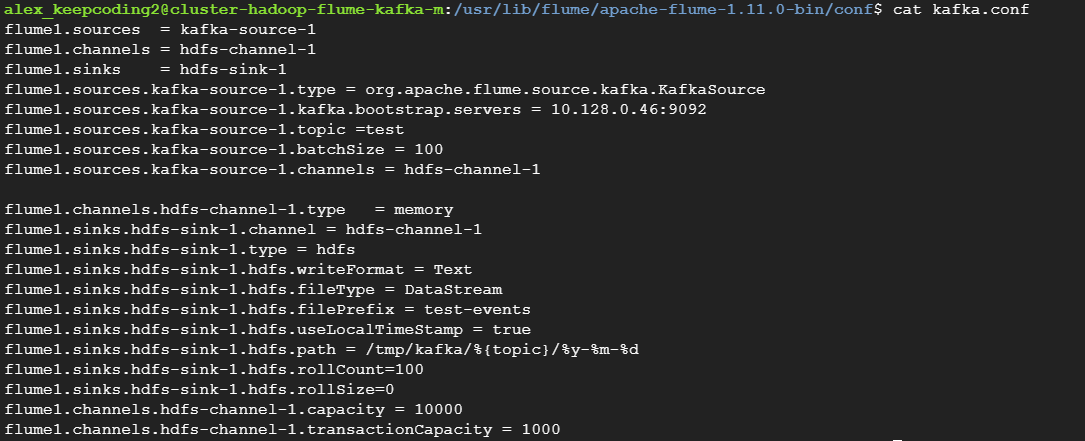

Ahora, una vez definido el archivo del consumer, lo arrancamos con Flume:

```
flume-ng agent -Xms100m -Xmx2000m -n flume1 -c conf -f kafka.conf - Dflume.root.logger=INFO,console
```

# **¡¡¡¡Ya lo tenemos!!!!**

Ahora, cada mensaje que envíamos en el productor que arrancamos en Kafka, se va a desviar al sink de HDFS (Hadoop Distributed File System).

El resultado, es decir, todo lo que enviemos, debería aparecer en:

```
hdfs dfs -ls -R /tmp/kafka/

hdfs dfs -cat /tmp/kafka/test/******/*

AQUÍ EN *** DEBEMOS PONER EL NOMBRE DE LA CARPETA, QUE SERÁ ALGO COMO LA FECHA DE HOY
```

(Abramos una nueva consola del cluster de Hadoop para verlo y enviemos algunos mensajes!)

Ah, antes de enviar algún mensaje, no existirá el "/tmp/kafka"

Enhorabuena, en este notebook hacemos muchas cosas, y, si has llegado
hasta aquí, ya conoces un bucket importante de herramientas Cloud con el que empezar a desenvolverte por tu cuenta con un poquito de práctica.

¿Qué hemos hecho en este notebook?



*   Hemos conocido y entendido para qué sirve Apache Kafka y sus componentes principales (Producers, Consumers, Brokers, Topics...)
*   Hemos conocido ZooKeeper y su importancia de la mano de Kafka
*   También hemos visto un ejemplo práctico de para qué sirve Apache Kafka en el mundo real
*   Montamos un server Kafka
  *   Lo instalamos y configuramos
  *   Arrancamos el servicio ZooKeeper
  *   Arrancamos Kafka
  *   Creamos un Topic
*   Creamos un cluster Hadoop en el que instalamos Flume
  *   Hemos conocido Flume y su utilidad junto con Kafka
  *   Configuramos Flume
*   Logramos que nuestro cluster Hadoop reciba en HDFS los mensajes que enviamos a través del server Kafka!

